- scanpy (sc) → analyzing single-cell data
- anndata (ad) → storing single-cell data efficiently
- pooch → downloading and caching datasets

In [3]:
import scanpy as sc
import anndata as ad
import pooch

In [5]:
sc.settings.set_figure_params(dpi=50, facecolor='white')

### 🧪 **What experiment was done?**
- The cells were **measured** (analyzed) using a technique called **10X Multiome**.
  
  **10X Multiome** = A very cool technology that does **two things at once** for each cell:
  1. **Gene Expression** → Measures which genes are turned "on" or "off" inside the cell.
     - (RNA-seq at the single-cell level.)
  2. **Chromatin Accessibility** → Measures **which parts of the DNA are open** and active.
     - (This tells us about *potential* gene regulation.)

  So it's **multi-omics** = multiple types of information *from the same cell*!


### 🧠 **Why is this important?**
- Having **both** gene expression **and** chromatin accessibility together helps researchers deeply understand **how genes are regulated**.
- Instead of looking at just "what the cell is doing" (gene expression), you can also see "how the cell is allowed to do it" (chromatin openness).

In [4]:
EXAMPLE_DATA = pooch.create(
    path=pooch.os_cache('scanpy basics'),
    base_url="doi:10.6084/m9.figshare.22716739.v1/",
)
EXAMPLE_DATA.load_registry_from_doi()

In [5]:
# Dictionary mapping sample IDs to their corresponding filenames
samples = {
    "s1d1": "s1d1_filtered_feature_bc_matrix.h5",
    "s1d3": "s1d3_filtered_feature_bc_matrix.h5",
}

# Empty dictionary to hold the loaded AnnData objects
adatas = {}

# Loop over each sample ID and filename pair
for sample_id, filename in samples.items():
    # Download the file if not already cached and get the local path
    path = EXAMPLE_DATA.fetch(filename)

    # Read the 10X Genomics formatted .h5 file into an AnnData object
    sample_adata = sc.read_10x_h5(path)

    # Ensure that gene names (variables) are unique to avoid duplication issues
    sample_adata.var_names_make_unique()

    # Store the AnnData object in the dictionary using the sample ID as the key
    adatas[sample_id] = sample_adata

# Concatenate all the individual AnnData objects into a single AnnData
# Add a new column 'sample' in the .obs to keep track of the sample origin
adata = ad.concat(adatas, label='sample')

# Ensure that all cell names (observation names) are unique across samples
adata.obs_names_make_unique()

# Print the number of cells from each sample to verify the merge
print(adata.obs['sample'].value_counts())

# Show a summary of the combined AnnData object
adata

/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


sample
s1d1    8785
s1d3    8340
Name: count, dtype: int64


/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 17125 × 36601
    obs: 'sample'

## Quality Control

In [6]:
# Mark mitochondrial genes by checking if the gene name starts with "MT-" (human)
adata.var["mt"] = adata.var_names.str.startswith("MT-")

# Mark ribosomal genes by checking if the gene name starts with "RPS" or "RPL"
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))

# Mark hemoglobin genes by checking if the gene name starts with "HB" but not "HBP" (excluding "P" for pseudogenes)
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [7]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"],
    inplace=True,
    log1p=True
)

In [8]:
# List all available columns in .obs
print(adata.obs.columns)

Index(['sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb',
       'log1p_total_counts_hb', 'pct_counts_hb'],
      dtype='object')


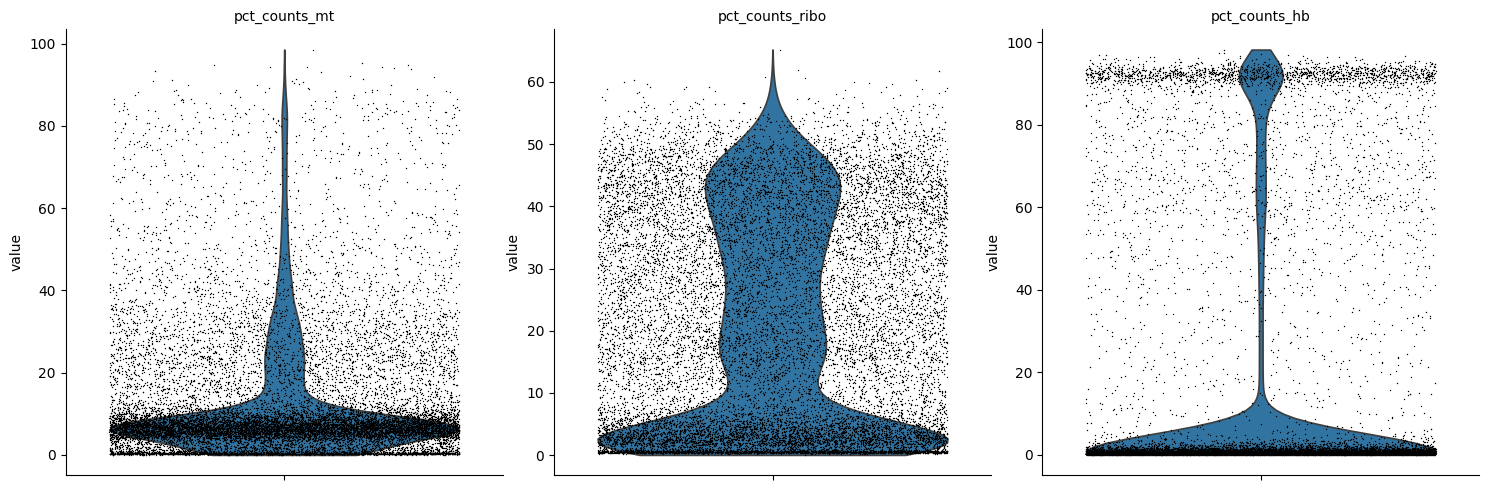

In [9]:
# Violin plot to visualize QC metrics
sc.pl.violin(adata, ["pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"],
             jitter=0.4, multi_panel=True)

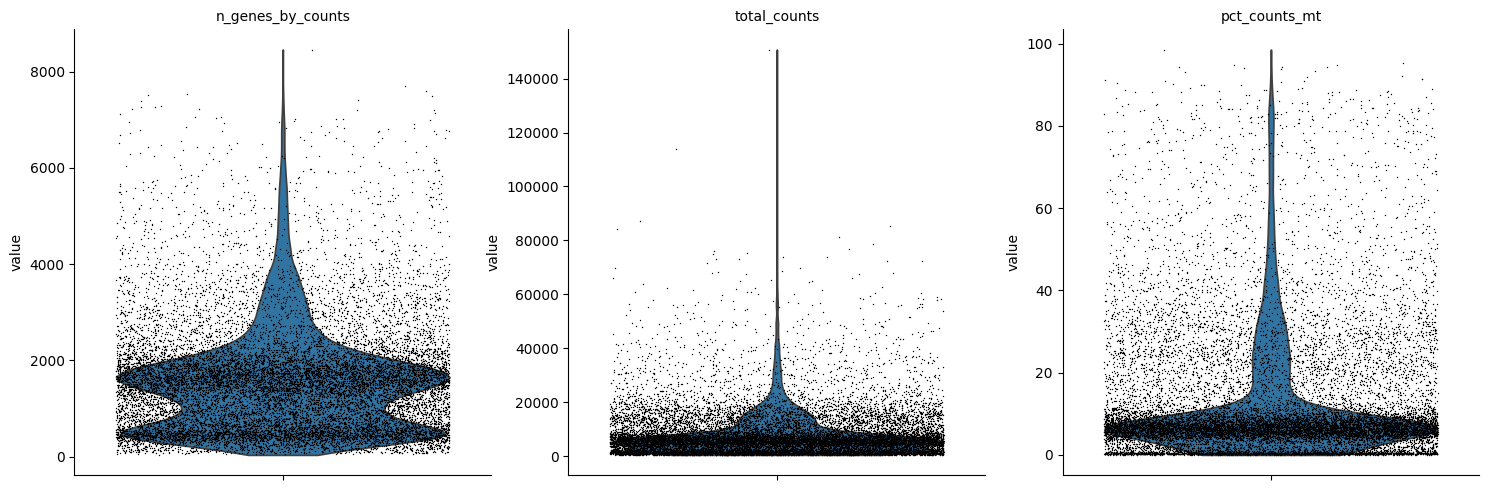

In [10]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

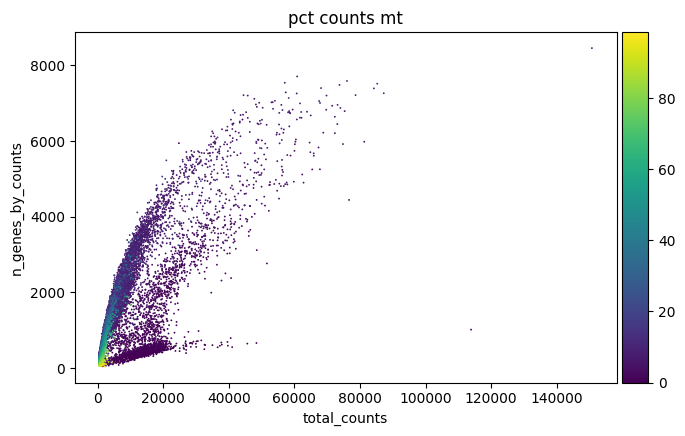

In [11]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [12]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

## Doublet detection

### What is a Doublet?

In single-cell RNA sequencing (scRNA-seq), a **doublet** refers to an event where two cells are captured in a single droplet or well during the experiment, leading to a mixture of transcriptomes from both cells. This can cause a misleading signal because the sequenced reads will contain RNA from two distinct cells, which can distort downstream analyses, such as clustering, gene expression profiling, and cell type identification.

Doublets are a common problem in scRNA-seq, and they can significantly impact the accuracy of the analysis. For example, doublets can lead to misclassifications, where two different cell types are mistaken for a single cell type or a new hybrid cell type, or they can create distorted or confusing gene expression patterns.

### Doublet Detection with Scrublet

**Scrublet** is a popular algorithm used for detecting doublets in single-cell RNA sequencing data. It works by comparing the observed transcriptomes of cells to simulated doublets. Scrublet creates synthetic doublets by mixing the transcriptomes of two randomly selected cells and then uses a nearest-neighbor classifier to distinguish between true cells and doublets based on the observed gene expression patterns.

In Scanpy, the doublet detection method is implemented through the function `scanpy.pp.scrublet()`, which adds two important attributes to the `.obs` attribute of the `AnnData` object:

1. **`doublet_score`**: A continuous score indicating the likelihood that a cell is a doublet. A higher score means that the cell is more likely to be a doublet.
2. **`predicted_doublet`**: A binary prediction (True/False) indicating whether the cell is predicted to be a doublet based on a threshold score.

### How Scrublet Works
- **Step 1**: **Simulate Doublets**: Scrublet generates synthetic doublets by randomly combining pairs of single-cell transcriptomes.
- **Step 2**: **Nearest-Neighbor Classifier**: It compares the observed cells to the simulated doublets using a nearest-neighbor approach to assess how similar a given cell is to the simulated doublets.
- **Step 3**: **Prediction**: Based on the comparison, it assigns a doublet score and predicts whether a cell is likely a doublet.



In [13]:
sc.pp.scrublet(adata, batch_key="sample")

## Normalization


**Normalization in Preprocessing**  
The next preprocessing step is **normalization**, where we adjust for differences in sequencing depth across cells. A common method is **count depth scaling**, followed by a **log1p transformation**.  
Count depth scaling means rescaling each cell’s total counts to a common value (like the **median count**, **10,000** counts (CP10k), or **1 million** counts (CPM)).  
The `target_sum` parameter in `sc.pp.normalize_total` controls this scaling value.  
After scaling, applying **log1p** (`log(x + 1)`) helps stabilize variance across genes.  
This combination (scaling + log1p) is called **log1PF normalization**.

In [14]:
# save count data
adata.layers['counts'] = adata.X.copy()

In [15]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

## Feature Selection


**Feature Selection: Highly Variable Genes**  
After normalization, we perform **feature selection** to reduce dimensionality and focus only on the most **informative genes**.  
This is done using `sc.pp.highly_variable_genes()`, which identifies **highly variable genes (HVGs)** — genes showing the most meaningful differences across cells.  
Scanpy's method can mimic the approaches from **Seurat**, **Cell Ranger**, or **Seurat v3**, depending on the `flavor` you choose.  
Selecting HVGs helps improve downstream tasks like clustering, visualization, and trajectory analysis.

In [16]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")

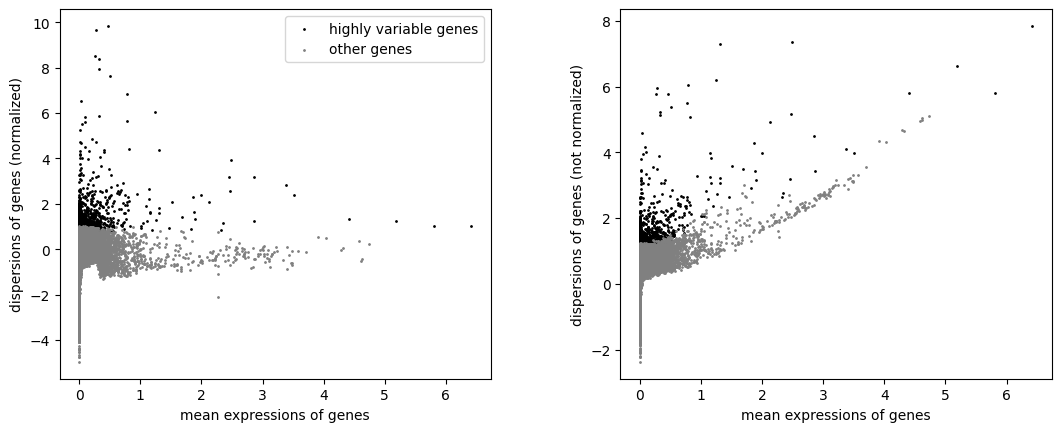

In [17]:
sc.pl.highly_variable_genes(adata)

## Dimensionality Reduction


**Dimensionality Reduction: PCA**  
Next, we apply **Principal Component Analysis (PCA)** using `sc.tl.pca(adata)` to reduce the data’s dimensionality, denoise it, and find the main directions of variation.  
To decide how many principal components (PCs) to use for further steps like clustering (`leiden()`) or visualization (`tsne()`), we inspect the **variance explained** by each PC with:

```python
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)
```

Overestimating the number of PCs usually isn’t harmful.  
We also plot the PCs to check if any unwanted effects (like batch effects or QC metrics) are driving major variation. If so, we can take steps to correct for them.

In [18]:
sc.tl.pca(adata)

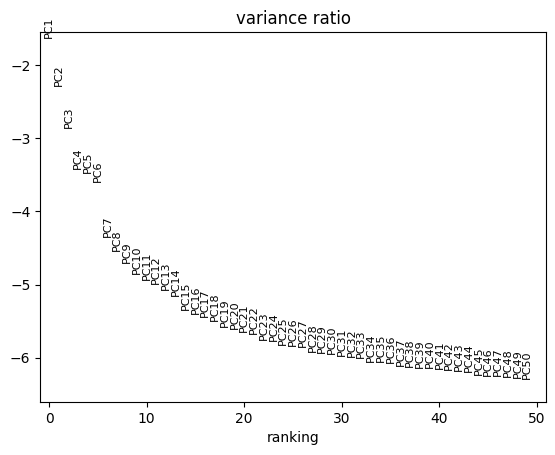

In [19]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

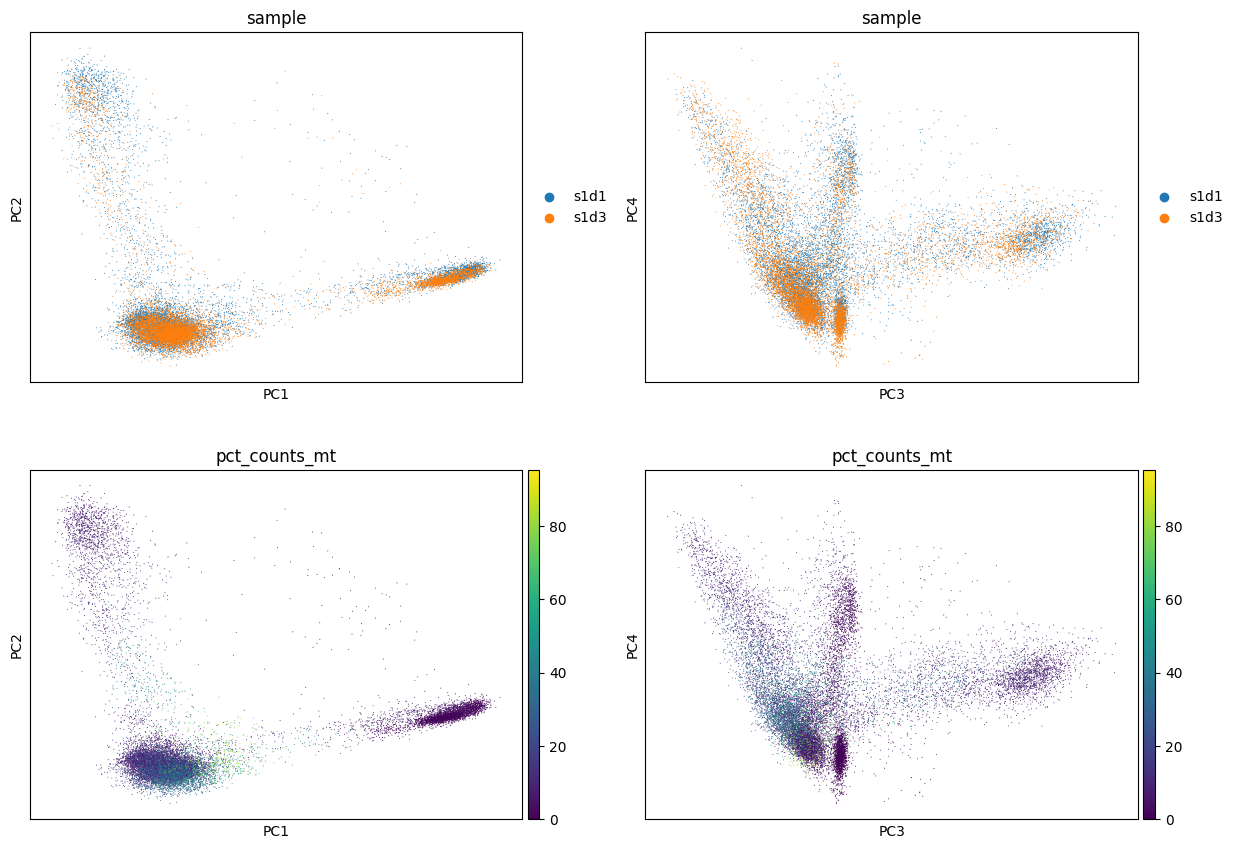

In [20]:
sc.pl.pca(
    adata,
    color=["sample", "sample", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

## Nearest neighbor graph constuction and visualization

In [21]:
sc.pp.neighbors(adata)

In [22]:
sc.tl.umap(adata)

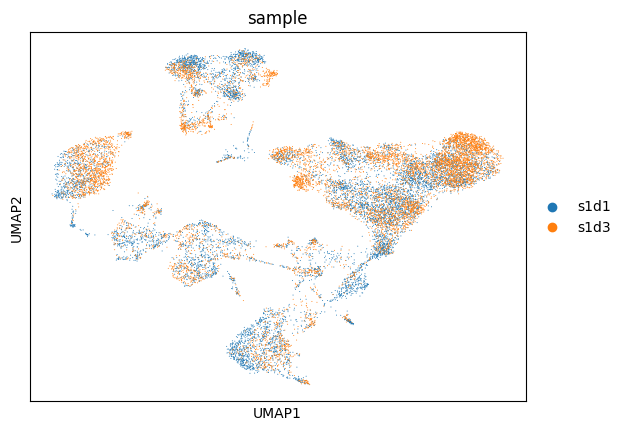

In [23]:
sc.pl.umap(
    adata,
    color = 'sample',
    size = 2,
)

## Clustering


**Clustering: Leiden Algorithm**  
Following Seurat and other frameworks, we use the **Leiden clustering method** (`sc.tl.leiden`) for identifying cell groups.  
Leiden is a **graph-based clustering** algorithm that detects communities by **optimizing modularity**.  
It **works directly** on the **neighborhood graph** of cells that we computed earlier during preprocessing.

In [26]:
# Using the igraph implementation and a fixed number of iterations can be significantly faster, especially for larger datasets
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)

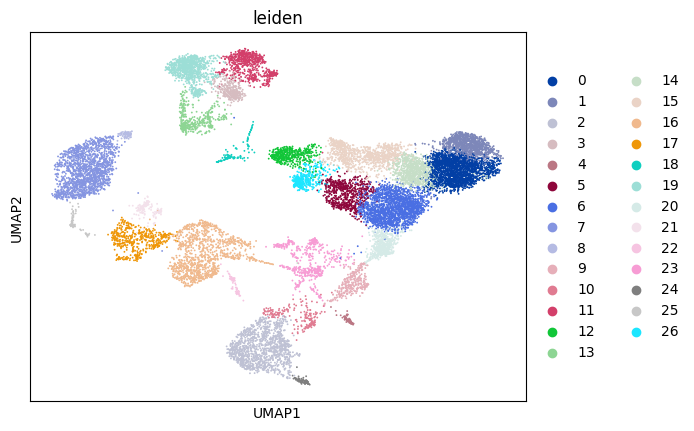

In [27]:
sc.pl.umap(adata, color=['leiden'])

## Re-assess quality control and cell filtering

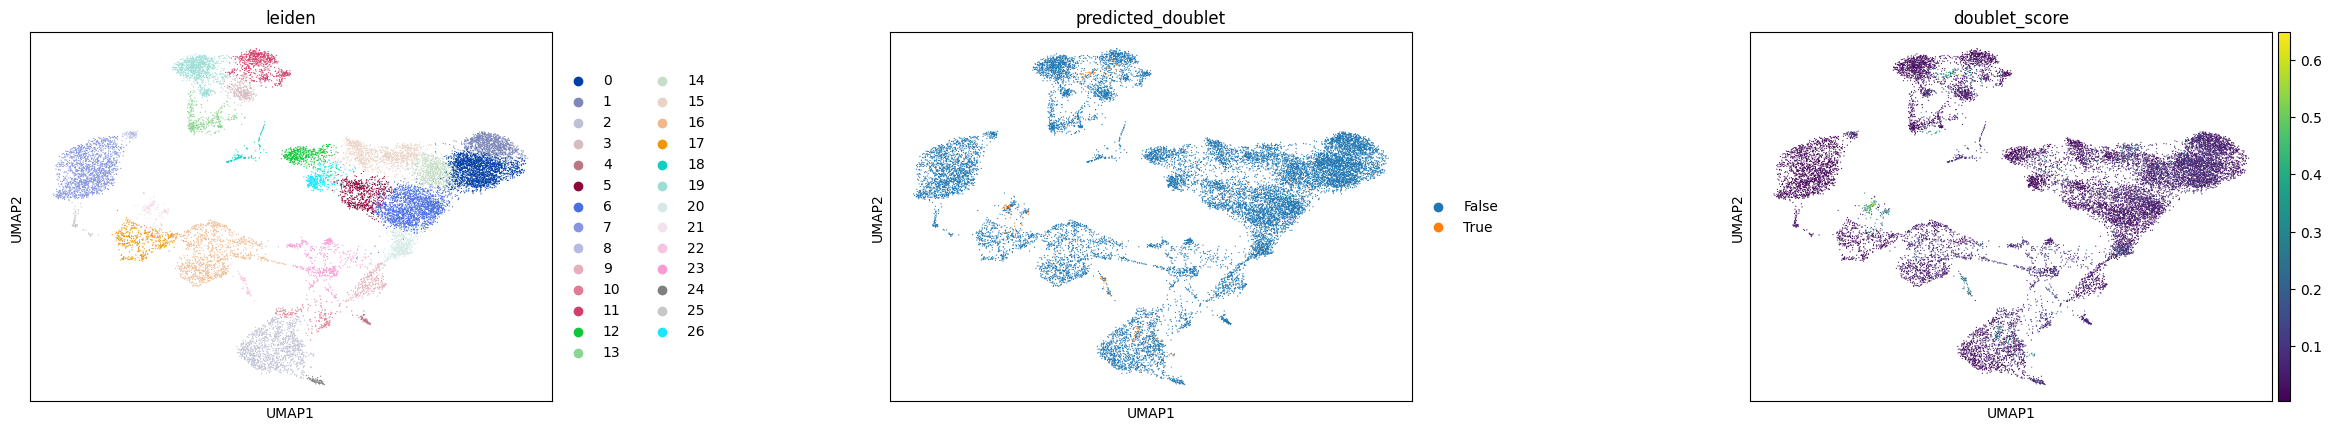

In [28]:
sc.pl.umap(
    adata,
    color=["leiden", "predicted_doublet", "doublet_score"],
    wspace = 0.5,
    size = 3,
)

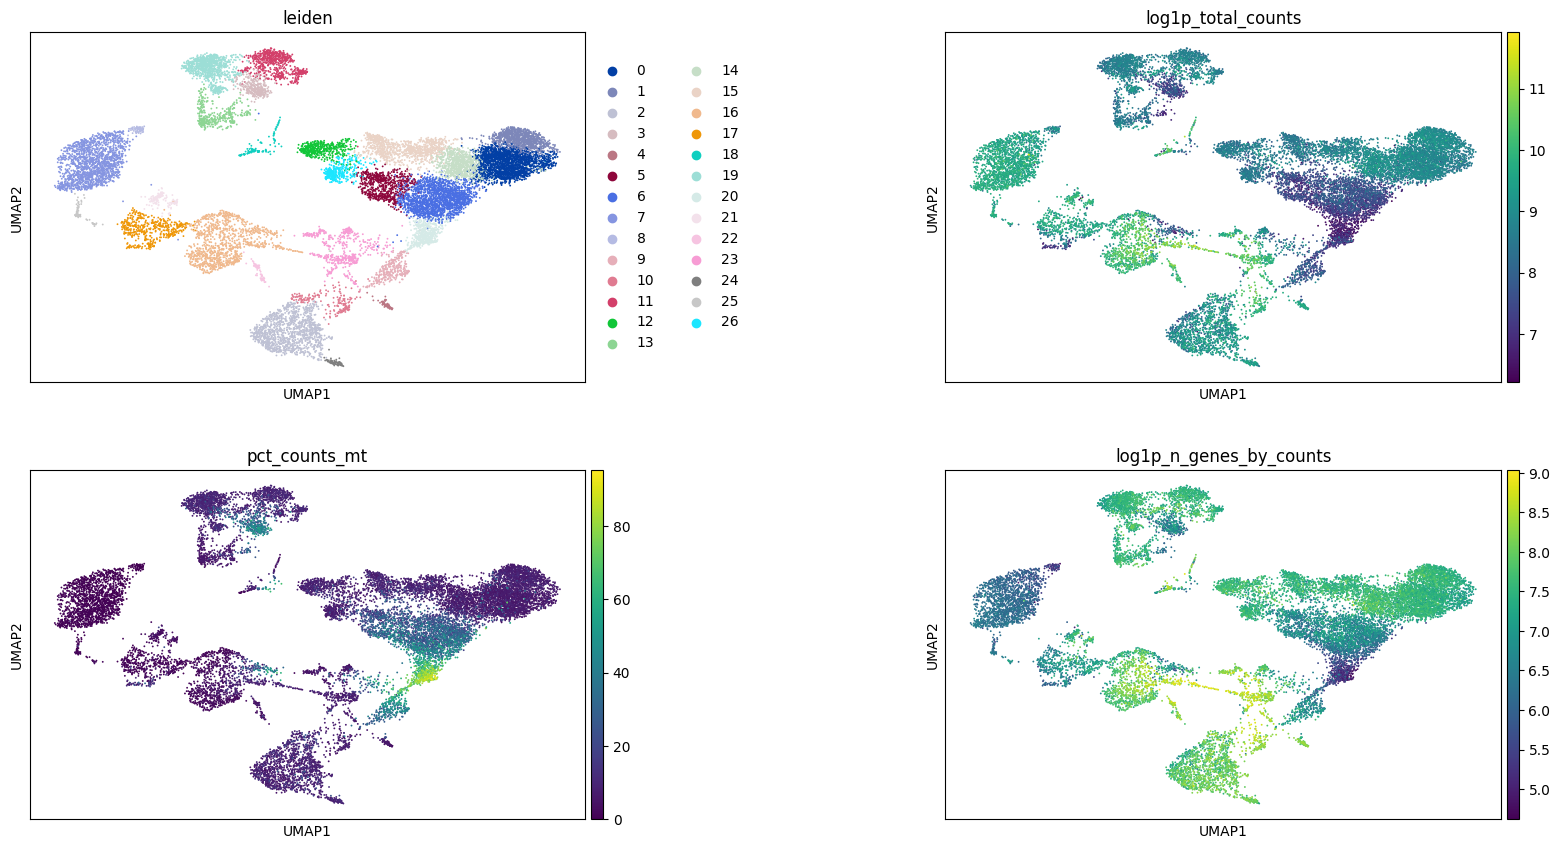

In [29]:
sc.pl.umap(
    adata,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
)

## Manual cell-type annotation


**Cell Type Annotation**  
Cell type annotation is a **labor-intensive and iterative** process, usually involving **subclustering** and **re-annotation**.  
After obtaining good-quality cells, we **assign cell types** based on **marker genes** — genes uniquely or highly expressed in specific cell types.  
Resources like **CellMarker**, **TF-Marker**, **PanglaoDB**, and tools like **cellxgene** help identify marker genes.  
Typically, **clusters** (e.g., generated by **Leiden clustering**) are first formed, and then annotated by examining marker gene expression across clusters.


In [30]:
for res in [0.02, 0.5, 2.0]:
    sc.tl.leiden(
        adata, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph"
    )

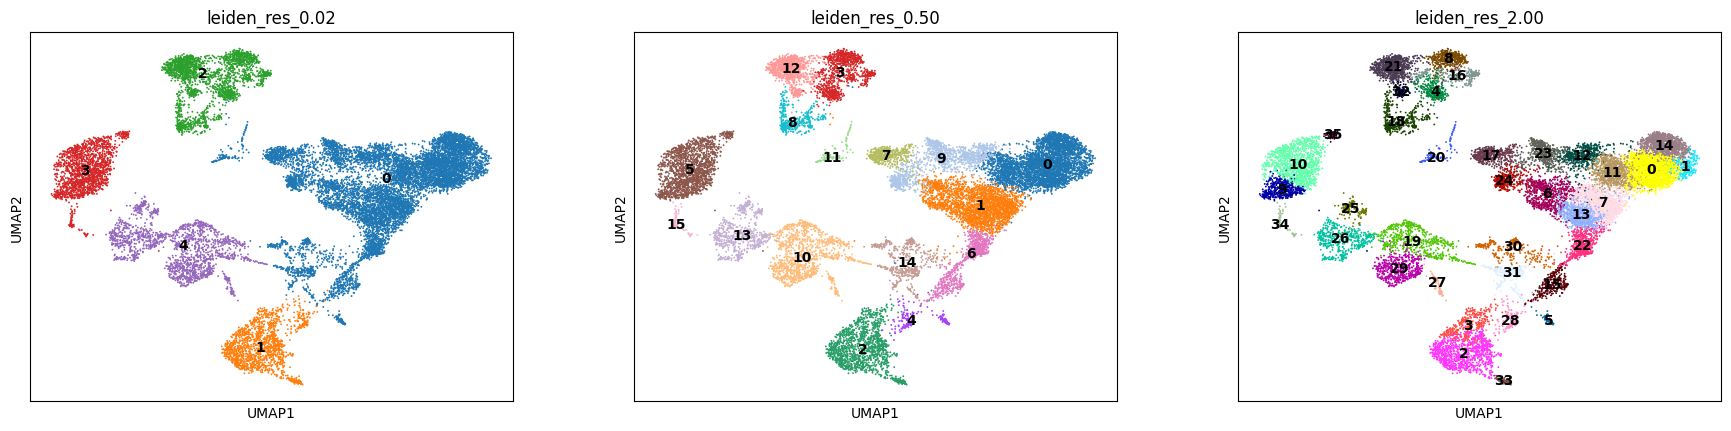

In [31]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.02", "leiden_res_0.50", "leiden_res_2.00"],
    legend_loc="on data",
)

## Marker gene set

In [32]:
marker_genes = {
    "CD14+ Mono": ["FCN1", "CD14"],
    "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"],
    # Note: DMXL2 should be negative
    "cDC2": ["CST3", "COTL1", "LYZ", "DMXL2", "CLEC10A", "FCER1A"],
    "Erythroblast": ["MKI67", "HBA1", "HBB"],
    # Note HBM and GYPA are negative markers
    "Proerythroblast": ["CDK6", "SYNGR1", "HBM", "GYPA"],
    "NK": ["GNLY", "NKG7", "CD247", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
    "ILC": ["ID2", "PLCG2", "GNLY", "SYNE1"],
    "Naive CD20+ B": ["MS4A1", "IL4R", "IGHD", "FCRL1", "IGHM"],
    # Note IGHD and IGHM are negative markers
    "B cells": [
        "MS4A1",
        "ITGB1",
        "COL4A4",
        "PRDM1",
        "IRF4",
        "PAX5",
        "BCL11A",
        "BLK",
        "IGHD",
        "IGHM",
    ],
    "Plasma cells": ["MZB1", "HSP90B1", "FNDC3B", "PRDM1", "IGKC", "JCHAIN"],
    # Note PAX5 is a negative marker
    "Plasmablast": ["XBP1", "PRDM1", "PAX5"],
    "CD4+ T": ["CD4", "IL7R", "TRBC2"],
    "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
    "T naive": ["LEF1", "CCR7", "TCF7"],
    "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
}

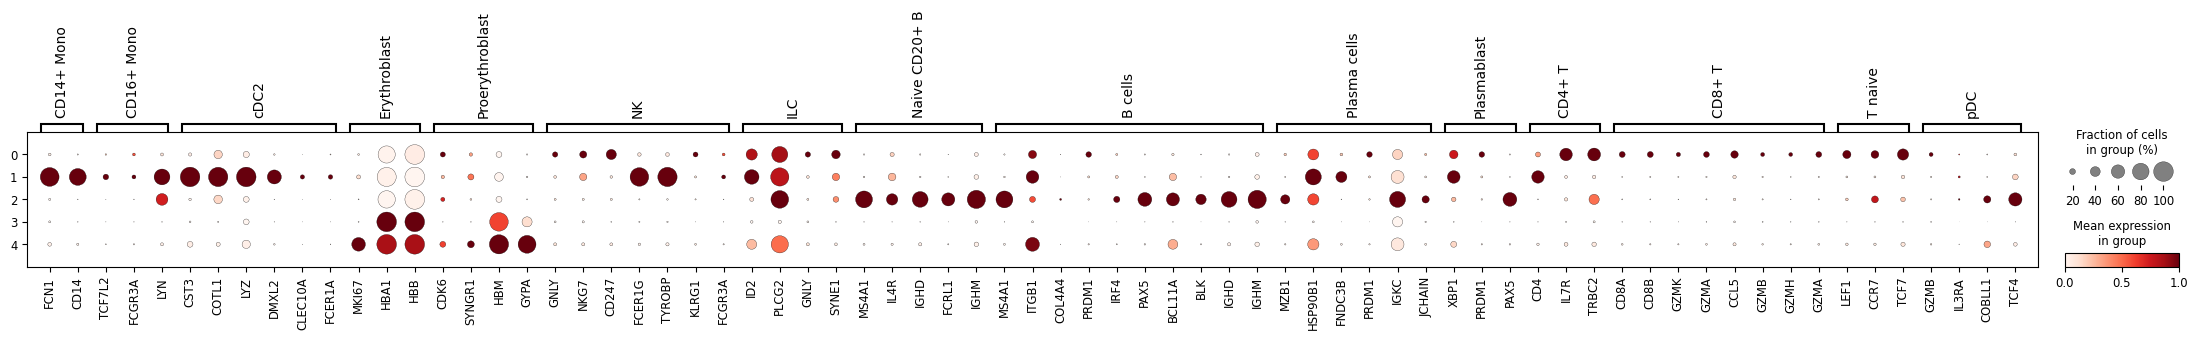

In [33]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden_res_0.02", standard_scale="var")

In [34]:
adata.obs["cell_type_lvl1"] = adata.obs["leiden_res_0.02"].map(
    {
        "0": "Lymphocytes",
        "1": "Monocytes",
        "2": "Erythroid",
        "3": "B Cells",
    }
)

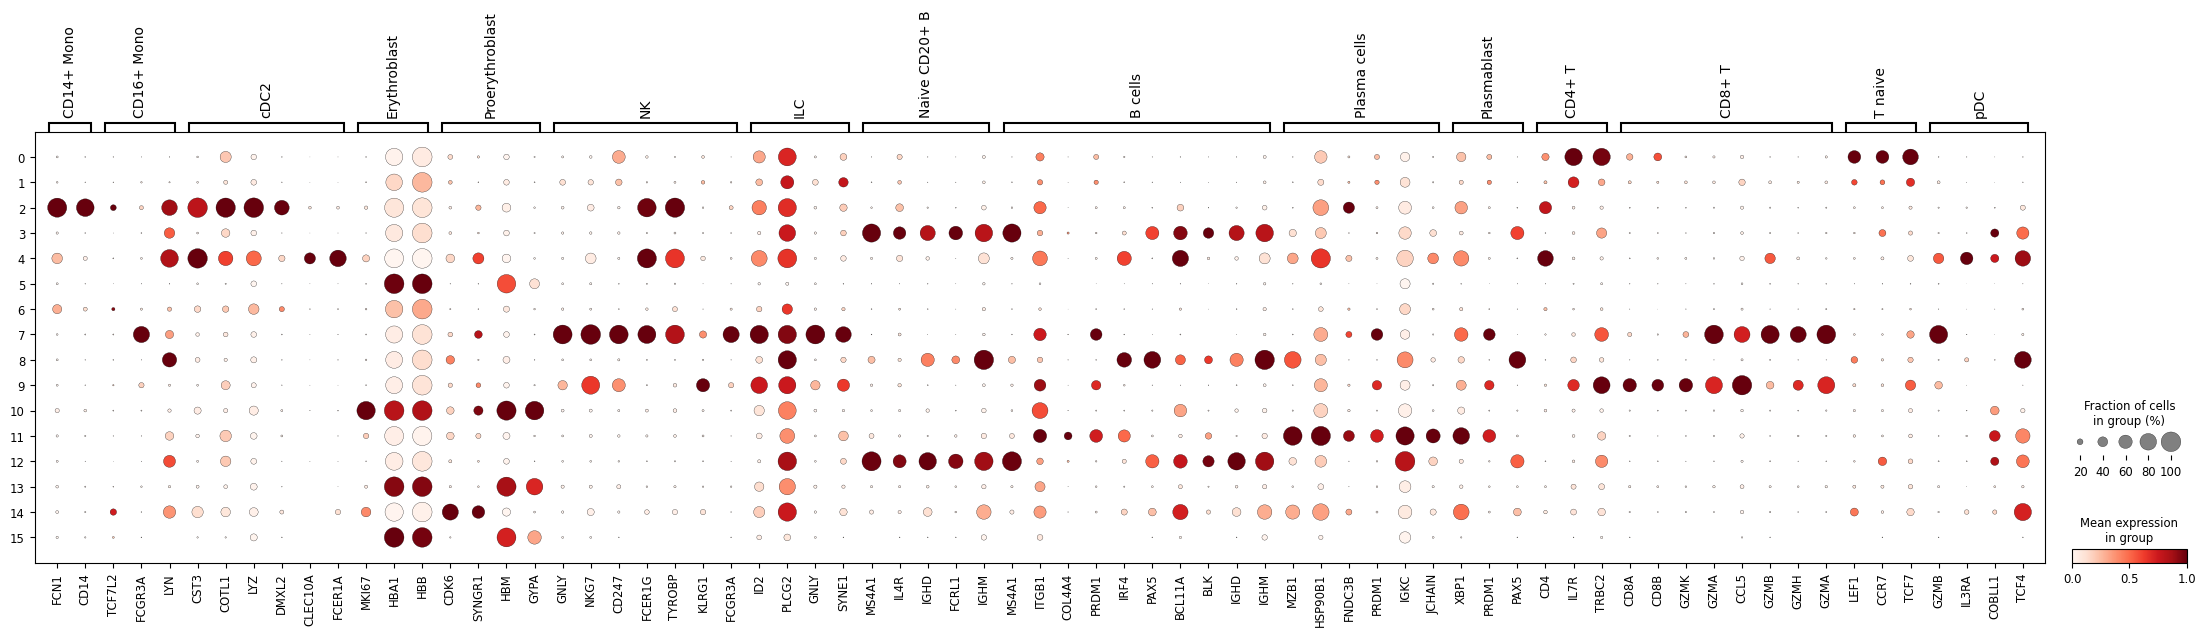

In [35]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden_res_0.50", standard_scale="var")

In [36]:
# Obtain cluster-specific differentially expressed genes
sc.tl.rank_genes_groups(adata, groupby="leiden_res_0.50", method="wilcoxon")

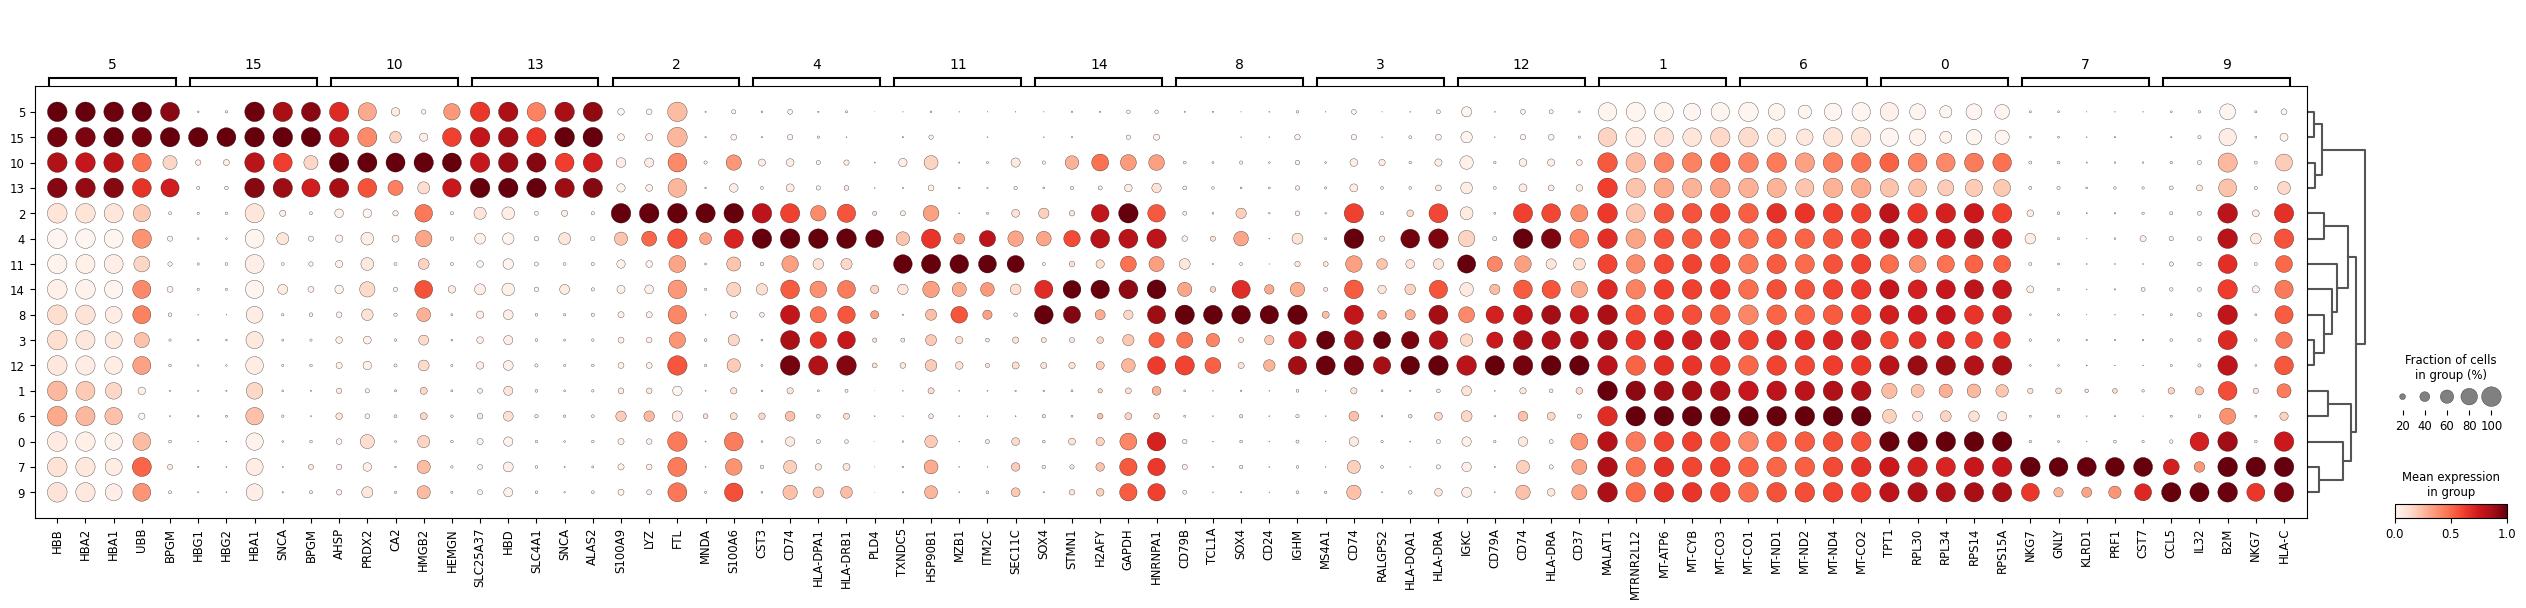

In [37]:
sc.pl.rank_genes_groups_dotplot(
    adata, groupby="leiden_res_0.50", standard_scale="var", n_genes=5
)

In [38]:
sc.get.rank_genes_groups_df(adata, group="7").head(5)

,names,scores,logfoldchanges,pvals,pvals_adj
0,NKG7,35.589638,6.536994,2.026411e-277,4.747273e-273
1,GNLY,34.022495,7.389986,1.035866e-253,1.213362e-249
2,KLRD1,33.894440,5.835429,8.044730e-252,6.282129e-248
3,PRF1,33.198444,5.444941,1.133603e-241,6.639227e-238
4,CST7,33.079052,5.231579,5.947836e-240,2.786799e-236


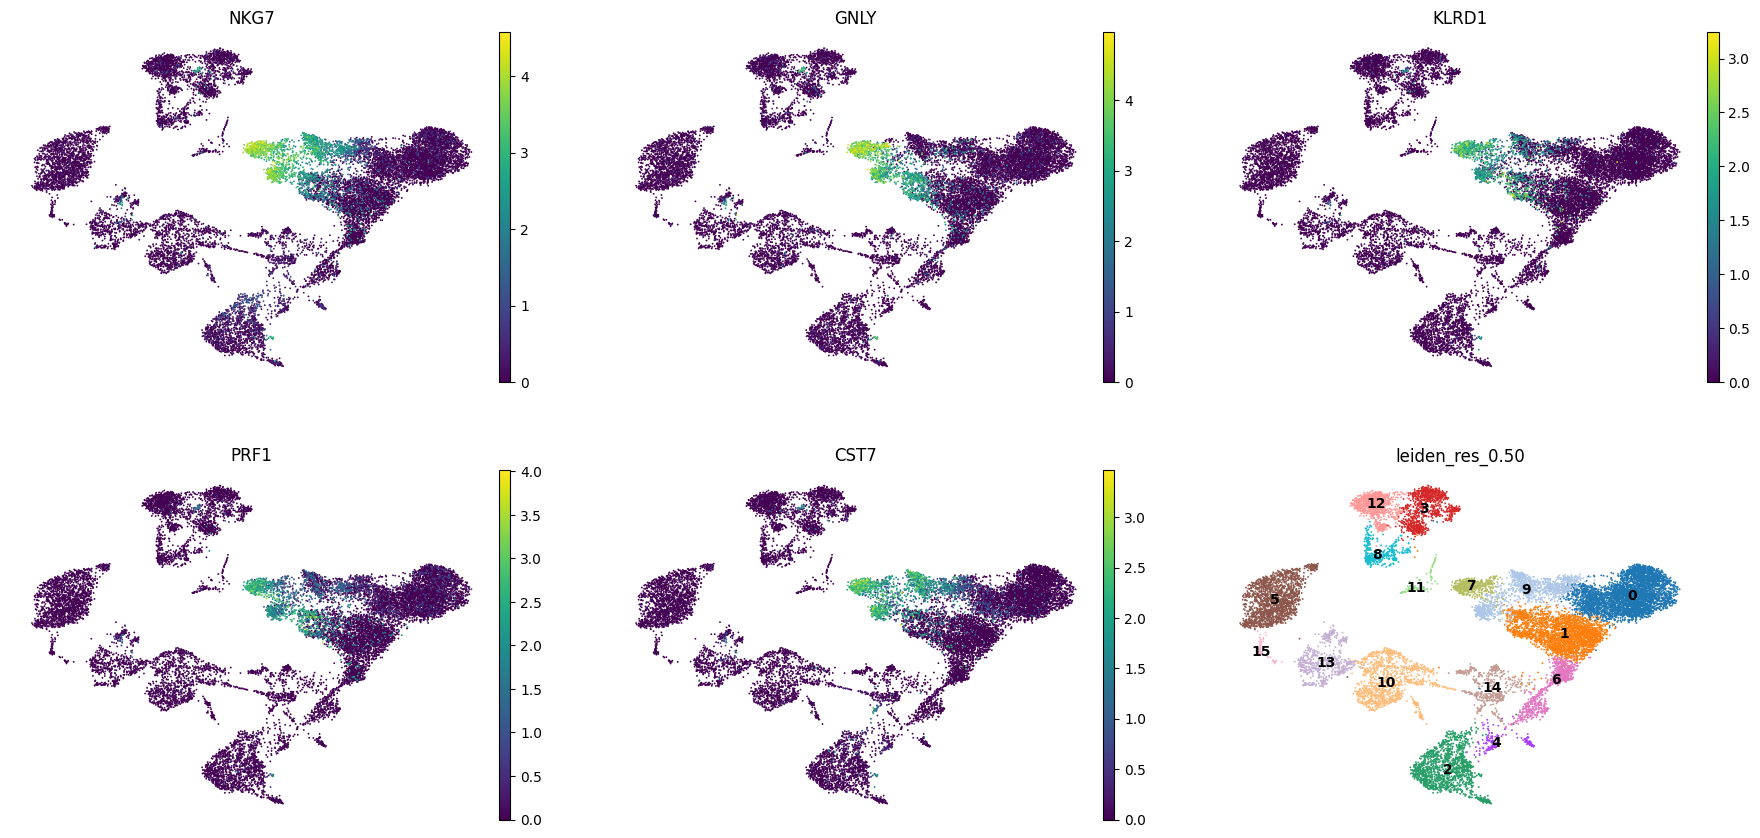

In [39]:
dc_cluster_genes = sc.get.rank_genes_groups_df(adata, group="7").head(5)["names"]
sc.pl.umap(
    adata,
    color=[*dc_cluster_genes, "leiden_res_0.50"],
    legend_loc="on data",
    frameon=False,
    ncols=3,
)